In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn sentence-transformers wordcloud kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ravitejavalluri","key":"4f8976292ee5a8a72152d48b9b01f210"}'}

In [3]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [4]:
!ls /root/.kaggle

kaggle.json


In [5]:
!kaggle datasets download -d yasserh/twitter-tweets-sentiment-dataset
!unzip twitter-tweets-sentiment-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/yasserh/twitter-tweets-sentiment-dataset
License(s): CC0-1.0
  0% 0.00/1.23M [00:00<?, ?B/s]
100% 1.23M/1.23M [00:00<00:00, 462MB/s]
Archive:  twitter-tweets-sentiment-dataset.zip
  inflating: Tweets.csv              


In [6]:
!ls

sample_data  Tweets.csv  twitter-tweets-sentiment-dataset.zip


## Project Objective
The objective of this project is to build a sentiment classification model using Sentence Transformer embeddings.
Tweets are converted into semantic embeddings and a machine learning model is trained to classify them into sentiment categories.

In [7]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("Tweets.csv")
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the dataset using visualizations.
In this section we analyze:

- Sentiment distribution
- Tweet length distribution
- Frequent words using Word Cloud

In [9]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


Index(['textID', 'text', 'selected_text', 'sentiment'], dtype='object')

In [10]:
df["sentiment"].value_counts()

,count
sentiment,
neutral,11118
positive,8582
negative,7781


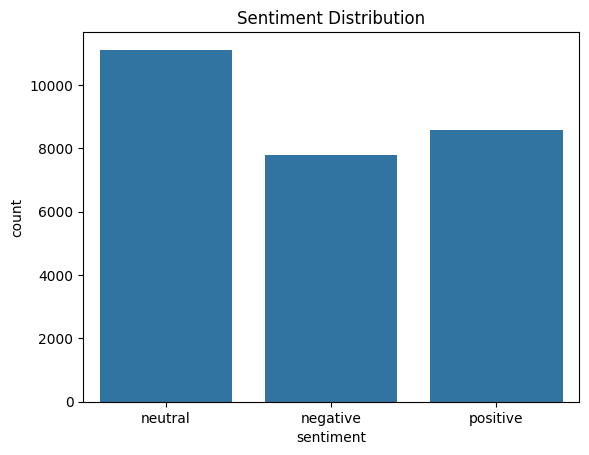

In [11]:
sns.countplot(x="sentiment", data=df)
plt.title("Sentiment Distribution")
plt.show()

## Word Cloud Visualization

A word cloud visualization highlights the most frequent words in the dataset.
Words that appear larger represent higher frequency in the tweets.
This helps us identify commonly used terms and patterns in the text data.

In [12]:
!pip install wordcloud

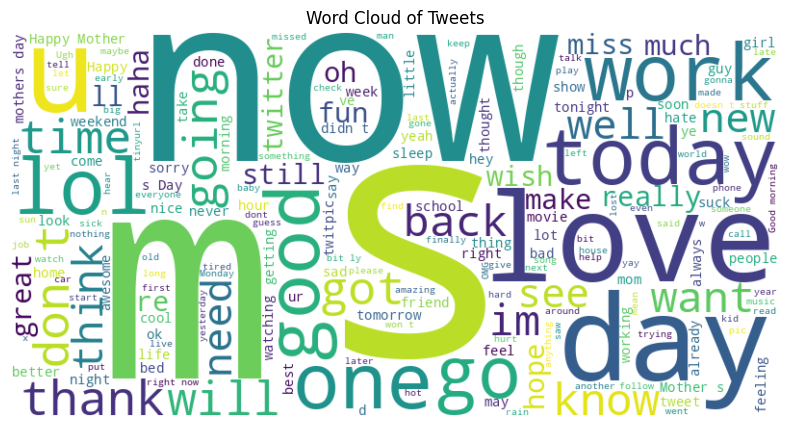

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all tweets
text = " ".join(df["text"].astype(str))

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

# Plot
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Tweets")
plt.show()

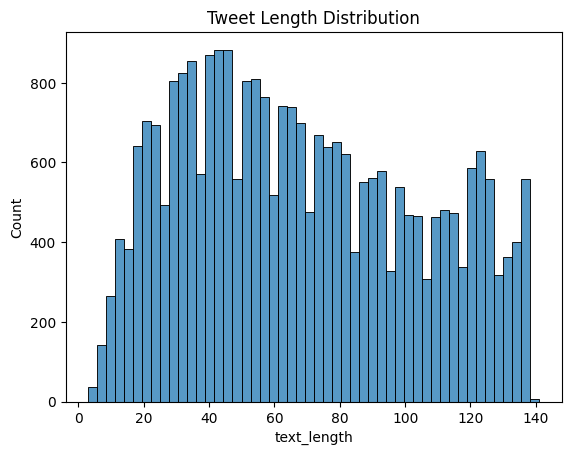

In [14]:
df["text_length"] = df["text"].astype(str).apply(len)

sns.histplot(df["text_length"], bins=50)
plt.title("Tweet Length Distribution")
plt.show()

In [15]:
def clean_text(text):
    text = str(text).lower()
    # Apply specific negation replacements first with very strong and common sentiment terms
    text = text.replace("not worst", "excellent")
    text = text.replace("not bad", "great")
    text = text.replace("not okay", "excellent") # Changed from 'acceptable' to 'excellent'
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df.head()

,textID,text,selected_text,sentiment,text_length,clean_text
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,36,id have responded if i were going
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,46,sooo sad i will miss you here in san diego
2,088c60f138,my boss is bullying me...,bullying me,negative,25,my boss is bullying me
3,9642c003ef,what interview! leave me alone,leave me alone,negative,31,what interview leave me alone
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,75,sons of why couldnt they put them on the relea...


In [16]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    df["clean_text"].tolist(),
    show_progress_bar=True
)

embeddings.shape

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/859 [00:00<?, ?it/s]

(27481, 384)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    embeddings,
    df["sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment"]
)

In [18]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [19]:
from sklearn.metrics import classification_report

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.71      0.69      0.70      1556
     neutral       0.65      0.70      0.67      2224
    positive       0.76      0.69      0.72      1717

    accuracy                           0.69      5497
   macro avg       0.70      0.69      0.70      5497
weighted avg       0.70      0.69      0.69      5497



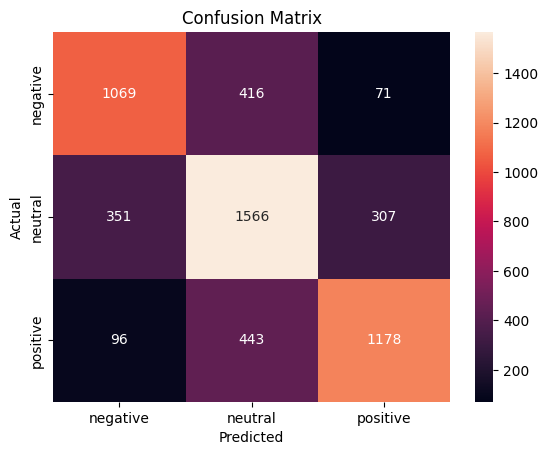

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred);

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=clf.classes_,
            yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [21]:
custom_tweets = [
    "I hate this Mobile!",
    "This service is terrible",
    "It is okay, nothing special",
    "Best experience in my life",
    "I am not happy with the results",
    "It is my worst experience ever"

]

cleaned = [clean_text(t) for t in custom_tweets]
custom_embeddings = model.encode(cleaned)

predictions = clf.predict(custom_embeddings)

for t, p in zip(custom_tweets, predictions):
    print(f"Tweet: {t}")
    print(f"Predicted Sentiment: {p}")
    print("-"*40)

Tweet: I hate this Mobile!
Predicted Sentiment: negative
----------------------------------------
Tweet: This service is terrible
Predicted Sentiment: negative
----------------------------------------
Tweet: It is okay, nothing special
Predicted Sentiment: positive
----------------------------------------
Tweet: Best experience in my life
Predicted Sentiment: positive
----------------------------------------
Tweet: I am not happy with the results
Predicted Sentiment: negative
----------------------------------------
Tweet: It is my worst experience ever
Predicted Sentiment: negative
----------------------------------------


## Insights and Observations

From the exploratory data analysis and model results, several observations can be made:

1. The sentiment distribution plot shows how tweets are divided across positive, negative, and neutral categories. Understanding this distribution helps determine whether the dataset is balanced.

2. The tweet length distribution indicates that most tweets are relatively short, which is expected due to Twitter’s character limit.

3. The word cloud visualization highlights frequently occurring words in the dataset. Larger words represent higher frequency, giving insight into common vocabulary used in tweets.

4. Sentence Transformer embeddings capture the semantic meaning of sentences, allowing the model to understand context rather than just individual words.

5. The Logistic Regression classifier performs well when trained on embeddings, demonstrating that embedding-based representations are effective for sentiment analysis tasks.

Overall, this project demonstrates how modern NLP techniques such as sentence embeddings can improve text classification performance.